In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

In [6]:
data=[[6.82, 118, 0],
                      [6.36, 125, 1],
                      [5.39, 99, 1],
                      [5.50, 106, 1],
                      [6.39, 148, 0],
                      [9.13, 148, 1],
                      [7.17, 147, 1],
                      [7.72, 72, 0]]
df=pd.DataFrame(data,columns=['cgpa','iq','is_placed'])
df

,cgpa,iq,is_placed
0,6.82,118,0
1,6.36,125,1
2,5.39,99,1
3,5.50,106,1
4,6.39,148,0
5,9.13,148,1
6,7.17,147,1
7,7.72,72,0


In [7]:
def count(is_placed):
    count = 0
    for i in range(len(is_placed)):
        if is_placed[i] == 1:
            count += 1
    return count

In [8]:
df['perd1']=np.log(count(df['is_placed'])/(df.shape[0]-count(df['is_placed'])))

In [9]:
df['pred1(probability)']=1/(1+np.exp(-np.log(5/3)))

In [ ]:
df.drop(columns=['pred1(probability'])

In [26]:
df['resd1']=df['is_placed']-df['pred1(probability)']
df.drop(columns=['leaf_entry1'])

,cgpa,iq,is_placed,perd1,pred1(probability),resd1
0,6.82,118,0,0.510826,0.625,-0.625
1,6.36,125,1,0.510826,0.625,0.375
2,5.39,99,1,0.510826,0.625,0.375
3,5.50,106,1,0.510826,0.625,0.375
4,6.39,148,0,0.510826,0.625,-0.625
5,9.13,148,1,0.510826,0.625,0.375
6,7.17,147,1,0.510826,0.625,0.375
7,7.72,72,0,0.510826,0.625,-0.625


In [27]:
from sklearn.tree import DecisionTreeRegressor
dt1=DecisionTreeRegressor(max_leaf_nodes=3)

In [28]:
dt1.fit(df.iloc[:,0:2].values, df.iloc[:,-1].values)

DecisionTreeRegressor(max_leaf_nodes=3)

<function matplotlib.pyplot.show(close=None, block=None)>

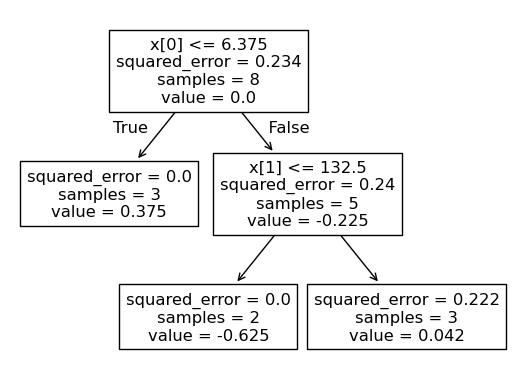

In [29]:
from sklearn.tree import plot_tree
plot_tree(dt1)
plt.show

In [30]:
df['leaf_entry1'] = dt1.apply(df.iloc[:,0:2])
df

C:\Users\Priti\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(


,cgpa,iq,is_placed,perd1,pred1(probability),leaf_entry1,resd1
0,6.82,118,0,0.510826,0.625,3,-0.625
1,6.36,125,1,0.510826,0.625,1,0.375
2,5.39,99,1,0.510826,0.625,1,0.375
3,5.50,106,1,0.510826,0.625,1,0.375
4,6.39,148,0,0.510826,0.625,4,-0.625
5,9.13,148,1,0.510826,0.625,4,0.375
6,7.17,147,1,0.510826,0.625,4,0.375
7,7.72,72,0,0.510826,0.625,3,-0.625


In [31]:
dt1.predict(df.iloc[:,0:2])

C:\Users\Priti\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(


array([-0.625     ,  0.375     ,  0.375     ,  0.375     ,  0.04166667,
        0.04166667,  0.04166667, -0.625     ])

In [45]:
def return_logs(leaf):
    temp_df=df[df['leaf_entry1']==leaf]
    num=temp_df['resd1'].sum()
    
    den=sum(temp_df['pred1(probability)']*(1-temp_df['pred1(probability)']))
    return round(num/den,2)

In [46]:
df.columns

Index(['cgpa', 'iq', 'is_placed', 'perd1', 'pred1(probability)', 'leaf_entry1',
       'resd1'],
      dtype='object')

In [47]:
df['pre2(log-odds)'] = df['perd1'] + df['leaf_entry1'].apply(return_logs)

In [49]:
df['pred2(probability)']=1/(1+np.exp(-df['pre2(log-odds)']))

In [52]:
df['resd2']=df['is_placed']-df['pred2(probability)']

In [53]:
df

,cgpa,iq,is_placed,perd1,pred1(probability),leaf_entry1,resd1,pre2(log-odds),pred2(probability),resd2
0,6.82,118,0,0.510826,0.625,3,-0.625,-2.159174,0.103477,-0.103477
1,6.36,125,1,0.510826,0.625,1,0.375,2.110826,0.891951,0.108049
2,5.39,99,1,0.510826,0.625,1,0.375,2.110826,0.891951,0.108049
3,5.50,106,1,0.510826,0.625,1,0.375,2.110826,0.891951,0.108049
4,6.39,148,0,0.510826,0.625,4,-0.625,0.690826,0.666151,-0.666151
5,9.13,148,1,0.510826,0.625,4,0.375,0.690826,0.666151,0.333849
6,7.17,147,1,0.510826,0.625,4,0.375,0.690826,0.666151,0.333849
7,7.72,72,0,0.510826,0.625,3,-0.625,-2.159174,0.103477,-0.103477


In [54]:
dt2=DecisionTreeRegressor(max_leaf_nodes=3)
dt2.fit(df.iloc[:,0:2].values,df.iloc[:,-1].values)

DecisionTreeRegressor(max_leaf_nodes=3)

<function matplotlib.pyplot.show(close=None, block=None)>

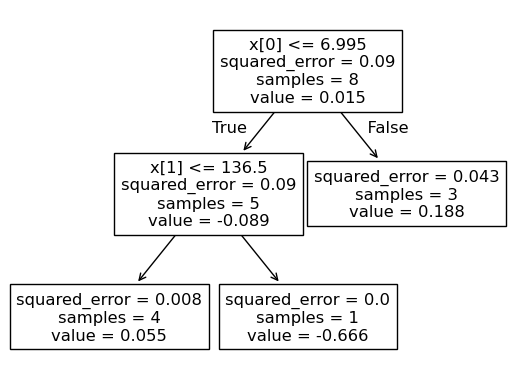

In [57]:
plot_tree(dt2)
plt.show

In [55]:
df['leaf_entry2']= dt2.apply(df.iloc[:,0:2])

C:\Users\Priti\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(


In [56]:
df

,cgpa,iq,is_placed,perd1,pred1(probability),leaf_entry1,resd1,pre2(log-odds),pred2(probability),resd2,leaf_entry2
0,6.82,118,0,0.510826,0.625,3,-0.625,-2.159174,0.103477,-0.103477,3
1,6.36,125,1,0.510826,0.625,1,0.375,2.110826,0.891951,0.108049,3
2,5.39,99,1,0.510826,0.625,1,0.375,2.110826,0.891951,0.108049,3
3,5.50,106,1,0.510826,0.625,1,0.375,2.110826,0.891951,0.108049,3
4,6.39,148,0,0.510826,0.625,4,-0.625,0.690826,0.666151,-0.666151,4
5,9.13,148,1,0.510826,0.625,4,0.375,0.690826,0.666151,0.333849,2
6,7.17,147,1,0.510826,0.625,4,0.375,0.690826,0.666151,0.333849,2
7,7.72,72,0,0.510826,0.625,3,-0.625,-2.159174,0.103477,-0.103477,2


In [64]:
def return_log2(leaf):
    temp_df=df[df['leaf_entry2']==leaf]
    num=temp_df['resd2'].sum()
    den=sum(temp_df['pred2(probability)']*(1-temp_df['pred2(probability)']))
    return round(num/den,2)

In [65]:
df.columns

Index(['cgpa', 'iq', 'is_placed', 'perd1', 'pred1(probability)', 'leaf_entry1',
       'resd1', 'pre2(log-odds)', 'pred2(probability)', 'resd2',
       'leaf_entry2'],
      dtype='object')

In [66]:
df['pred3(log-odds)']=df['perd1']+df['pre2(log-odds)']+df['leaf_entry2'].apply(return_log2)

In [67]:
df

,cgpa,iq,is_placed,perd1,pred1(probability),leaf_entry1,resd1,pre2(log-odds),pred2(probability),resd2,leaf_entry2,pred3(log-odds)
0,6.82,118,0,0.510826,0.625,3,-0.625,-2.159174,0.103477,-0.103477,3,-1.068349
1,6.36,125,1,0.510826,0.625,1,0.375,2.110826,0.891951,0.108049,3,3.201651
2,5.39,99,1,0.510826,0.625,1,0.375,2.110826,0.891951,0.108049,3,3.201651
3,5.50,106,1,0.510826,0.625,1,0.375,2.110826,0.891951,0.108049,3,3.201651
4,6.39,148,0,0.510826,0.625,4,-0.625,0.690826,0.666151,-0.666151,4,-1.798349
5,9.13,148,1,0.510826,0.625,4,0.375,0.690826,0.666151,0.333849,2,2.251651
6,7.17,147,1,0.510826,0.625,4,0.375,0.690826,0.666151,0.333849,2,2.251651
7,7.72,72,0,0.510826,0.625,3,-0.625,-2.159174,0.103477,-0.103477,2,-0.598349


In [74]:
df['pred3(probability)']=1/(1+np.exp(-df['pred3(log-odds)']))

In [76]:
df

,cgpa,iq,is_placed,perd1,pred1(probability),leaf_entry1,resd1,pre2(log-odds),pred2(probability),resd2,leaf_entry2,pred3(log-odds),pred3(probability),res_final
0,6.82,118,0,0.510826,0.625,3,-0.625,-2.159174,0.103477,-0.103477,3,-1.068349,0.255717,-0.255717
1,6.36,125,1,0.510826,0.625,1,0.375,2.110826,0.891951,0.108049,3,3.201651,0.960896,0.039104
2,5.39,99,1,0.510826,0.625,1,0.375,2.110826,0.891951,0.108049,3,3.201651,0.960896,0.039104
3,5.50,106,1,0.510826,0.625,1,0.375,2.110826,0.891951,0.108049,3,3.201651,0.960896,0.039104
4,6.39,148,0,0.510826,0.625,4,-0.625,0.690826,0.666151,-0.666151,4,-1.798349,0.142052,-0.142052
5,9.13,148,1,0.510826,0.625,4,0.375,0.690826,0.666151,0.333849,2,2.251651,0.904793,0.095207
6,7.17,147,1,0.510826,0.625,4,0.375,0.690826,0.666151,0.333849,2,2.251651,0.904793,0.095207
7,7.72,72,0,0.510826,0.625,3,-0.625,-2.159174,0.103477,-0.103477,2,-0.598349,0.354722,-0.354722


In [77]:
df['res_final']=df['is_placed']-df['pred3(probability)']
df[['resd1','resd2','res_final']]

,resd1,resd2,res_final
0,-0.625,-0.103477,-0.255717
1,0.375,0.108049,0.039104
2,0.375,0.108049,0.039104
3,0.375,0.108049,0.039104
4,-0.625,-0.666151,-0.142052
5,0.375,0.333849,0.095207
6,0.375,0.333849,0.095207
7,-0.625,-0.103477,-0.354722


In [78]:
# point 7.2,100(predicting the output with different data points)

In [81]:
y_pred=0.510826+dt1.predict([[7.2,100]])+dt2.predict([[7.2,100]])

In [82]:
y_pred

array([0.07389995])

In [84]:
def predict(final_output):
  if final_output>0.5:
     return 1
  else:
      return 0
    

In [85]:
final_output=1/(1+np.exp(-y_pred))
print(predict(final_output))

1
